# Eksempel på beregning: fart og akselerasjon fra målt posisjon

Vi har målt posisjonen til en gjenstand med jevne mellomrom (hvert sekund). Ut ifra disse (diskrete) posisjonsmålingene kan vi regne ut gjennomsnittsfarten mellom hvert målepunkt, og deretter gjennomsnittsakselerasjonen mellom hvert fartspunkt. Til slutt plotter vi alle tre størrelsene.

Fart:         [2. 3. 4. 5. 6.] m/s
Akselerasjon: [1. 1. 1. 1.] m/s^2


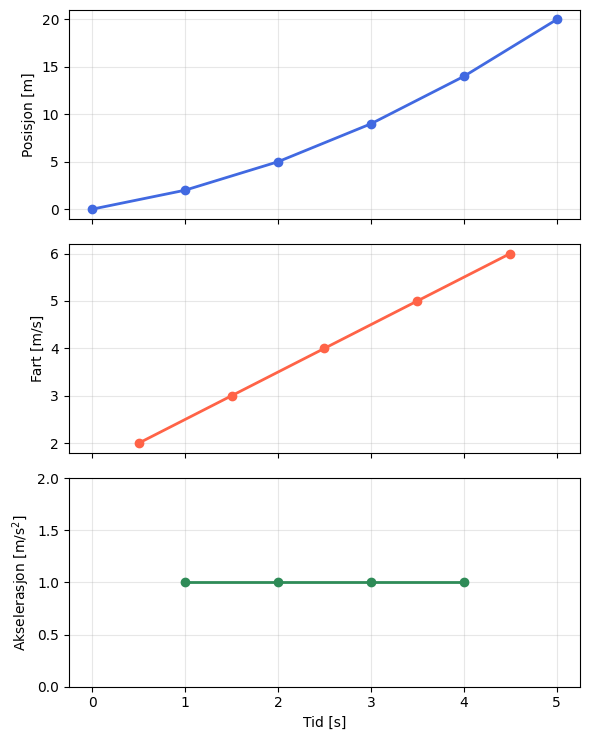

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Malt posisjon som funksjon av tid
t = np.array([0, 1, 2, 3, 4, 5])       # tid [s]
s = np.array([0, 2, 5, 9, 14, 20])     # posisjon [m]

# Gjennomsnittsfart mellom hvert malepunkt: v = delta_s / delta_t
v = np.diff(s) / np.diff(t)            # fart [m/s]
t_v = (t[:-1] + t[1:]) / 2             # tidspunkt (midtpunkt) for hver fart

# Gjennomsnittsakselerasjon mellom hvert fartspunkt: a = delta_v / delta_t
a = np.diff(v) / np.diff(t_v)          # akselerasjon [m/s^2]
t_a = (t_v[:-1] + t_v[1:]) / 2         # tidspunkt (midtpunkt) for hver akselerasjon

print(f"Fart:         {v} m/s")
print(f"Akselerasjon: {a} m/s^2")

fig, axs = plt.subplots(3, 1, figsize=(6, 7.5), sharex=True)

axs[0].plot(t, s, 'o-', color='royalblue', linewidth=2)
axs[0].set_ylabel('Posisjon [m]')
axs[0].grid(True, alpha=0.3)

axs[1].plot(t_v, v, 'o-', color='tomato', linewidth=2)
axs[1].set_ylabel('Fart [m/s]')
axs[1].grid(True, alpha=0.3)

axs[2].plot(t_a, a, 'o-', color='seagreen', linewidth=2)
axs[2].set_ylabel('Akselerasjon [m/s$^2$]')
axs[2].set_xlabel('Tid [s]')
axs[2].set_ylim(0, 2)
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Eksakte uttrykk for fart og strekning

Akselerasjonen vi regnet ut over var (tilnaermet) konstant. Nar akselerasjonen er konstant, kan vi finne eksakte, kontinuerlige uttrykk for fart og strekning ved a integrere - i stedet for a bare regne ut noen fa punkter slik vi gjorde over.

Sammenhengen mellom posisjon, fart og akselerasjon er:

$$v(t) = \int a(t)\, dt \qquad \text{og} \qquad s(t) = \int v(t)\, dt$$

Farten er altsa integralet av akselerasjonen, og strekningen er integralet av farten.

Siden akselerasjonen er konstant lik $a$, gir forste integrasjon:

$$v(t) = a t + v_0$$

der $v_0$ er farten ved $t = 0$ (en integrasjonskonstant vi ma bestemme). Integrerer vi en gang til, far vi strekningen:

$$s(t) = \frac{1}{2} a t^2 + v_0 t + s_0$$

der $s_0$ er posisjonen ved $t = 0$.

Vi finner $v_0$ og $s_0$ ved a kreve at det eksakte uttrykket for $s(t)$ stemmer med de malte posisjonene ved $t = 0$ og $t = 1$. Cellen under gjor denne utregningen med sympy og viser de eksakte uttrykkene med LaTeX, og de to neste cellene plotter de eksakte kurvene sammen med de numeriske (malte/utregnede) verdiene i samme figur.

In [ ]:
import sympy as sp

# Akselerasjonen vi fant over er konstant - bruker gjennomsnittet som verdien
a_verdi = a.mean()  # m/s^2

t_sym, v0, s0 = sp.symbols('t v0 s0')

# Integrerer akselerasjonen en gang -> eksakt uttrykk for farten
v_uttrykk = sp.integrate(a_verdi, t_sym) + v0

# Integrerer farten en gang til -> eksakt uttrykk for strekningen
s_uttrykk = sp.integrate(v_uttrykk, t_sym) + s0

# Bestemmer integrasjonskonstantene v0 og s0 ut fra de malte posisjonene
# ved t = 0 og t = 1 (de to forste malepunktene)
losning = sp.solve([
    s_uttrykk.subs(t_sym, t[0]) - s[0],
    s_uttrykk.subs(t_sym, t[1]) - s[1],
], [v0, s0])

v_eksakt_uttrykk = sp.simplify(v_uttrykk.subs(losning))
s_eksakt_uttrykk = sp.simplify(s_uttrykk.subs(losning))

print(f"Eksakt fart:      v(t) = {v_eksakt_uttrykk}")
print(f"Eksakt strekning: s(t) = {s_eksakt_uttrykk}")

# Gjor de eksakte uttrykkene om til vanlige python-funksjoner vi kan plotte
v_eksakt = sp.lambdify(t_sym, v_eksakt_uttrykk, 'numpy')
s_eksakt = sp.lambdify(t_sym, s_eksakt_uttrykk, 'numpy')

t_kontinuerlig = np.linspace(t[0], t[-1], 200)

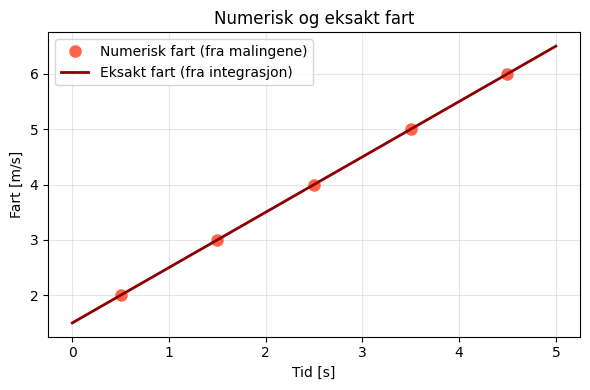

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(t_v, v, 'o', color='tomato', markersize=8, label='Numerisk fart (fra malingene)')
plt.plot(t_kontinuerlig, v_eksakt(t_kontinuerlig), '-', color='darkred', linewidth=2, label='Eksakt fart (fra integrasjon)')
plt.xlabel('Tid [s]')
plt.ylabel('Fart [m/s]')
plt.title('Numerisk og eksakt fart')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

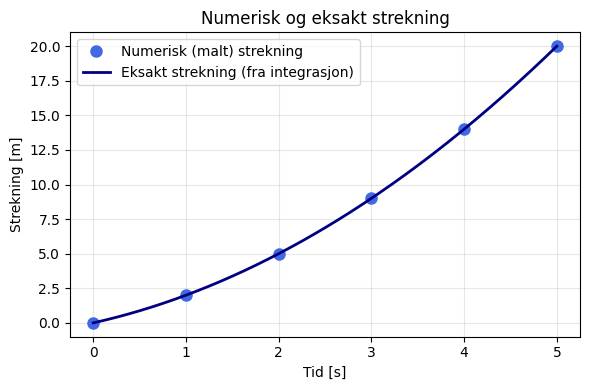

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(t, s, 'o', color='royalblue', markersize=8, label='Numerisk (malt) strekning')
plt.plot(t_kontinuerlig, s_eksakt(t_kontinuerlig), '-', color='navy', linewidth=2, label='Eksakt strekning (fra integrasjon)')
plt.xlabel('Tid [s]')
plt.ylabel('Strekning [m]')
plt.title('Numerisk og eksakt strekning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()